In [4]:
from google.colab import files
uploaded=files.upload()

Saving electric_vehicles_dataset.csv to electric_vehicles_dataset.csv


In [5]:
import pandas as pd
data=pd.read_csv('electric_vehicles_dataset.csv')
df=pd.DataFrame(data)
df.head()

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating
0,EV1001,BMW,Volt X 1,SUV,60,294,4.9,7.3,214,190,5821705,2019,4.8
1,EV1002,BMW,Eon EV 7,Hatchback,50,270,5.4,8.4,159,78,3863504,2026,4.4
2,EV1003,Kia,EcoRide 7,Hatchback,50,420,8.4,2.9,207,262,5505360,2023,3.0
3,EV1004,Kia,Falcon 1,SUV,30,252,8.4,1.4,214,191,936156,2023,4.0
4,EV1005,Nissan,Urban E 3,Hatchback,50,335,6.7,1.8,204,111,7164845,2023,3.8


In [3]:
#1.	Write a function to calculate the energy efficiency of a vehicle:
#Hint: Efficiency = Range / Battery_Capacity

def Calculate_Efficiency(Range,Battery_Capacity):
  return Range/Battery_Capacity
Calculate_Efficiency(294,60)

4.9

In [6]:
#2.	Write a function to classify vehicles
def cv(Efficiency):
  if Efficiency>8:
    return 'Excellent'
  elif 6<Efficiency<8:
    return 'Good'
  elif 4<Efficiency<6:
    return 'Average'
  elif Efficiency<4:
    return 'Poor'
  else:
    return None
df['Category']=df['Efficiency'].apply(cv)
df.head()

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating,Category
0,EV1001,BMW,Volt X 1,SUV,60,294,4.9,7.3,214,190,5821705,2019,4.8,Average
1,EV1002,BMW,Eon EV 7,Hatchback,50,270,5.4,8.4,159,78,3863504,2026,4.4,Average
2,EV1003,Kia,EcoRide 7,Hatchback,50,420,8.4,2.9,207,262,5505360,2023,3.0,Excellent
3,EV1004,Kia,Falcon 1,SUV,30,252,8.4,1.4,214,191,936156,2023,4.0,Excellent
4,EV1005,Nissan,Urban E 3,Hatchback,50,335,6.7,1.8,204,111,7164845,2023,3.8,Good


In [5]:
#3.	Find all vehicles whose: Range > 400 km , Charging time < 2 hours, Safety rating ≥ 4
df[(df['Range']>400) & (df['Charging_Time']<2) & (df['Safety_Rating']>=4)]

,Vehicle_ID,Manufacturer,Model,Vehicle_Type,Battery_Capacity,Range,Efficiency,Charging_Time,Top_Speed,Motor_Power,Price,Launch_Year,Safety_Rating,Category
27,EV1028,Tata,Drive Pro 3,Sedan,75,532,7.1,1.1,253,83,5447214,2025,4.3,Good


In [10]:
#numpy aggregations
import numpy as np
battery_mean=np.mean(df['Battery_Capacity'])
print("Battery Capacity mean:",battery_mean)
range_mean=np.mean(df['Range'])
print("Vehicle Range Mean:",range_mean)
sd_price=np.std(df['Price'])
print(f'Standard Deviation of Price: {sd_price:.2f}')
max_power=np.max(df['Motor_Power'])
print("Maximum Motor Power:",max_power)
min_charge=np.min(df['Charging_Time'])
print("Minimum Charging Time:",min_charge)

Battery Capacity mean: 58.6
Vehicle Range Mean: 380.2
Standard Deviation of Price: 2055455.17
Maximum Motor Power: 343
Minimum Charging Time: 0.8


In [11]:
#2.	Find the correlation coefficient between:
bcr=np.corrcoef(df['Battery_Capacity'],df['Range'])
print("Battery Capacity and Range",bcr)
pm=np.corrcoef(df['Price'],df['Motor_Power'])
print("Price and Motor Power",pm)
ctbc=np.corrcoef(df['Charging_Time'],df['Battery_Capacity'])
print("Charging Time and Battery Capacity",ctbc)

Battery Capacity and Range [[1.         0.88243976]
 [0.88243976 1.        ]]
Price and Motor Power [[ 1.         -0.11793431]
 [-0.11793431  1.        ]]
Charging Time and Battery Capacity [[1.         0.33484229]
 [0.33484229 1.        ]]


In [20]:
#Pandas
exp=df[df['Price']==df['Price'].max()]
print("Most Expensive Vehicle:",exp)
cheap=df[df['Price']==df['Price'].min()]
print("Cheapest Vehicle:",cheap)
max_range=df[df['Range']==df['Range'].max()]
print("Max Range Vehicle:",max_range)
high_eff=df[df['Efficiency']==df['Efficiency'].max()]
print("Highest Efficient Vehicle:",high_eff)

Most Expensive Vehicle:    Vehicle_ID Manufacturer     Model Vehicle_Type  Battery_Capacity  Range  \
34     EV1035          Kia  Falcon 2        Sedan                90    621   

    Efficiency  Charging_Time  Top_Speed  Motor_Power    Price  Launch_Year  \
34         6.9            5.0        121          242  8733546         2026   

    Safety_Rating Category  
34            3.6     Good  
Cheapest Vehicle:   Vehicle_ID Manufacturer     Model Vehicle_Type  Battery_Capacity  Range  \
3     EV1004          Kia  Falcon 1          SUV                30    252   

   Efficiency  Charging_Time  Top_Speed  Motor_Power   Price  Launch_Year  \
3         8.4            1.4        214          191  936156         2023   

   Safety_Rating   Category  
3            4.0  Excellent  
Max Range Vehicle:    Vehicle_ID Manufacturer     Model Vehicle_Type  Battery_Capacity  Range  \
21     EV1022          Kia  Volt X 1          SUV               100    800   

    Efficiency  Charging_Time  Top_Spe

In [21]:
#2.	Find manufacturer-wise:
#Average price
df.groupby('Manufacturer')['Price'].agg(['mean'])

,mean
Manufacturer,
BMW,4.827924e+06
BYD,4.824634e+06
Hyundai,4.174592e+06
Kia,5.070453e+06
MG,5.154408e+06
Mahindra,6.537284e+06
Mercedes-Benz,3.892796e+06
Nissan,5.065877e+06
Tata,3.859949e+06


In [25]:
#Average Range
df.groupby('Manufacturer')['Range'].agg(['mean'])


,mean
Manufacturer,
BMW,322.250000
BYD,353.200000
Hyundai,471.400000
Kia,550.000000
MG,395.375000
Mahindra,305.000000
Mercedes-Benz,180.000000
Nissan,318.428571
Tata,370.500000


In [23]:
#Average Battery Capacity
df.groupby('Manufacturer')['Battery_Capacity'].agg(['mean'])

,mean
Manufacturer,
BMW,58.125000
BYD,55.000000
Hyundai,65.000000
Kia,74.166667
MG,55.625000
Mahindra,53.333333
Mercedes-Benz,30.000000
Nissan,56.428571
Tata,58.750000


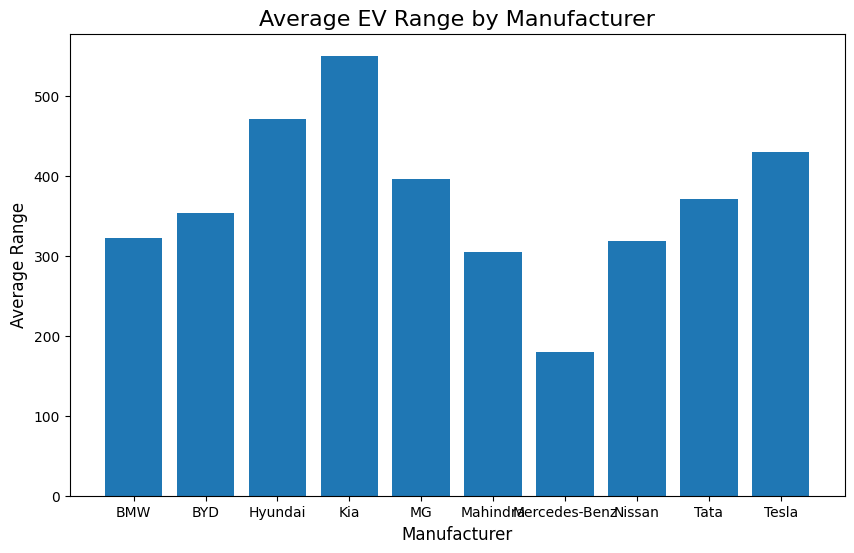

In [10]:
#1.	Bar chart: Plot Average range of each manufacturer.
import matplotlib.pyplot as plt
avg_range = df.groupby('Manufacturer')['Range'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.bar(avg_range['Manufacturer'], avg_range['Range'])
plt.title('Average EV Range by Manufacturer', fontsize=16)
plt.xlabel('Manufacturer', fontsize=12)
plt.ylabel('Average Range', fontsize=12)
plt.show()

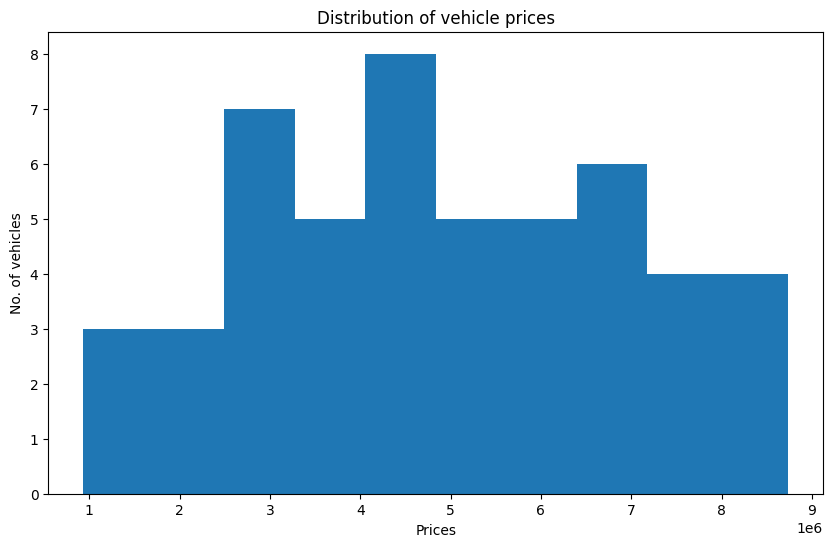

In [11]:
#2.	Histogram: Plot Distribution of vehicle prices.
plt.figure(figsize=(10, 6))
plt.hist(df['Price'])
plt.title("Distribution of vehicle prices")
plt.xlabel("Prices")
plt.ylabel("No. of vehicles")
plt.show()

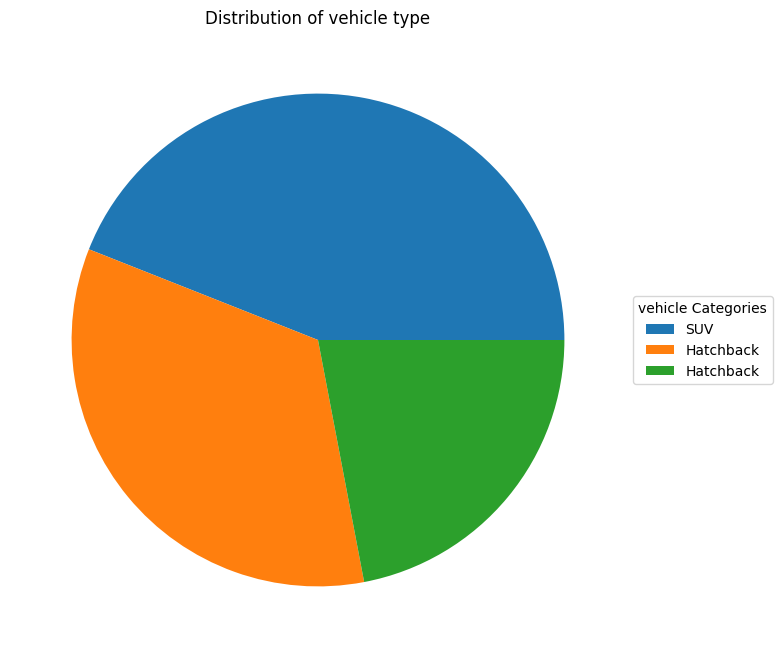

In [17]:
#3.	Pie chart: Vehicle type distribution.
plt.figure(figsize=(8, 8))
type_counts = df['Vehicle_Type'].value_counts()
plt.pie(type_counts)
plt.title("Distribution of vehicle type")
plt.legend(df['Vehicle_Type'],
    title="vehicle Categories",
    loc="center left",
    bbox_to_anchor=(1, 0.5))
plt.show()

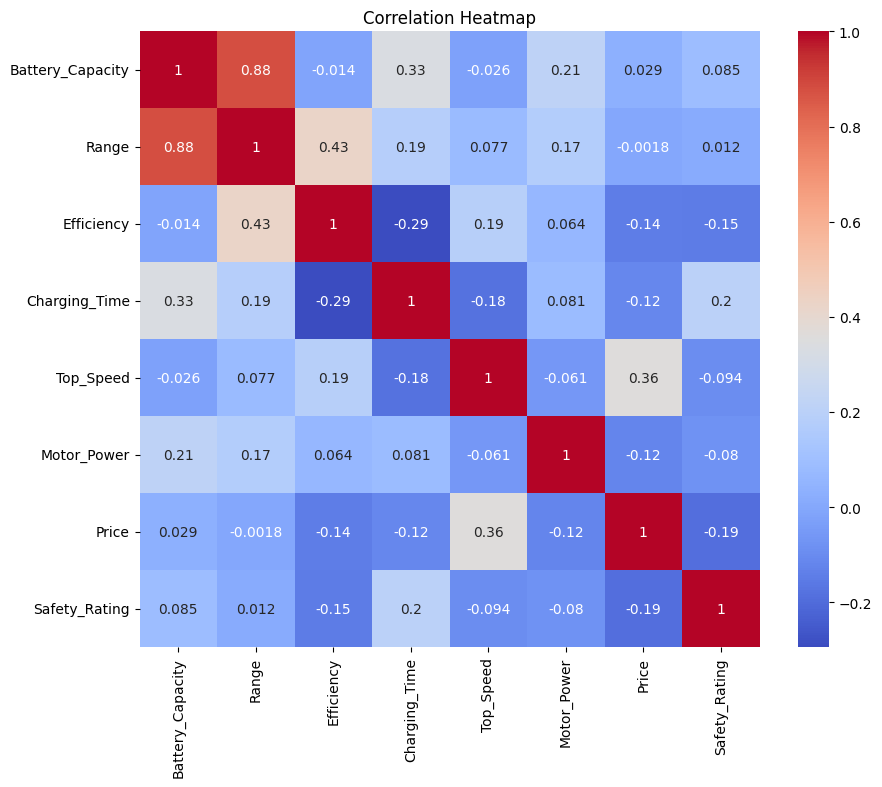

In [20]:
#Seaborn
#1.	Create a heatmap showing correlation among all numerical columns.
import seaborn as sns
target_cols = [
    "Battery_Capacity", "Range", "Efficiency", "Charging_Time",
    "Top_Speed", "Motor_Power", "Price", "Safety_Rating"
]
df_numerical = df[target_cols]
corr_matrix = df_numerical.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

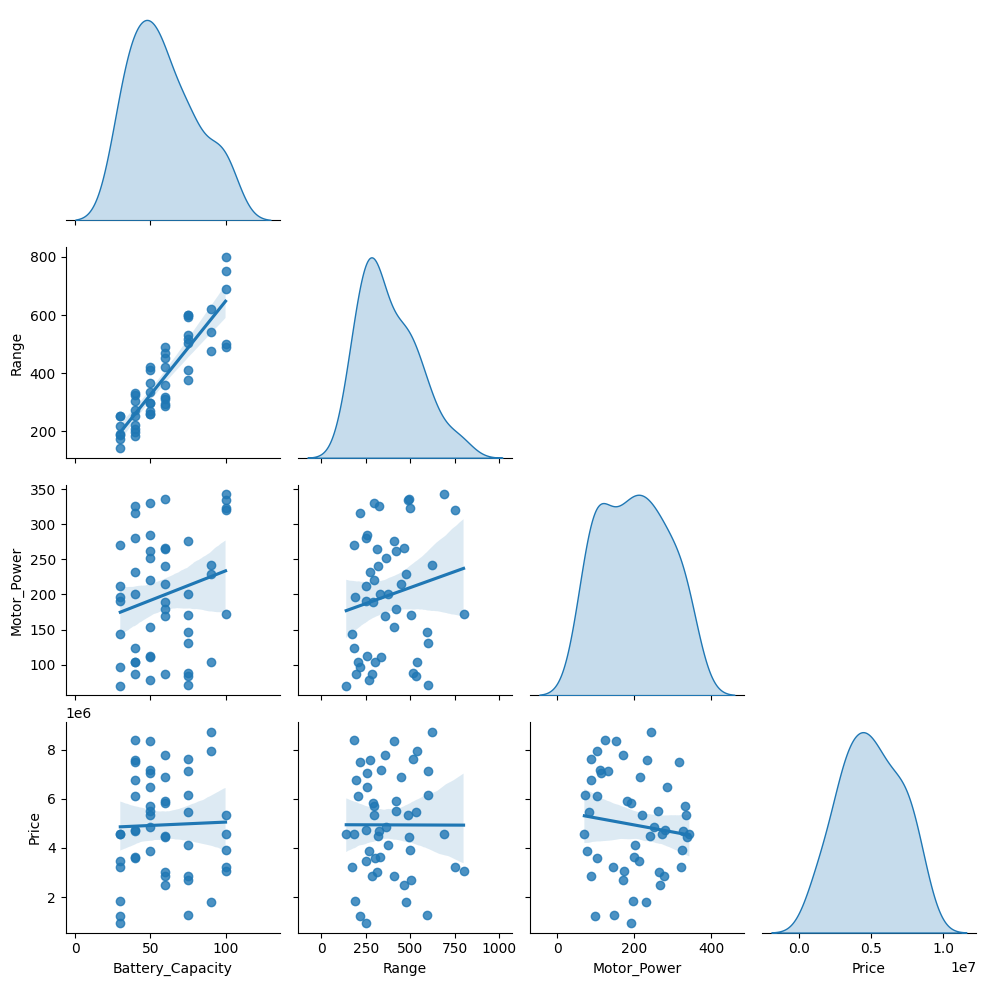

In [21]:
#2.	Create a pairplot for: Battery Capacity, Range, Motor Power, Price
pairplot_cols = ["Battery_Capacity", "Range", "Motor_Power", "Price"]
df_subset = df[pairplot_cols]
sns.pairplot(df_subset, kind="reg", diag_kind="kde", corner=True)
plt.show()

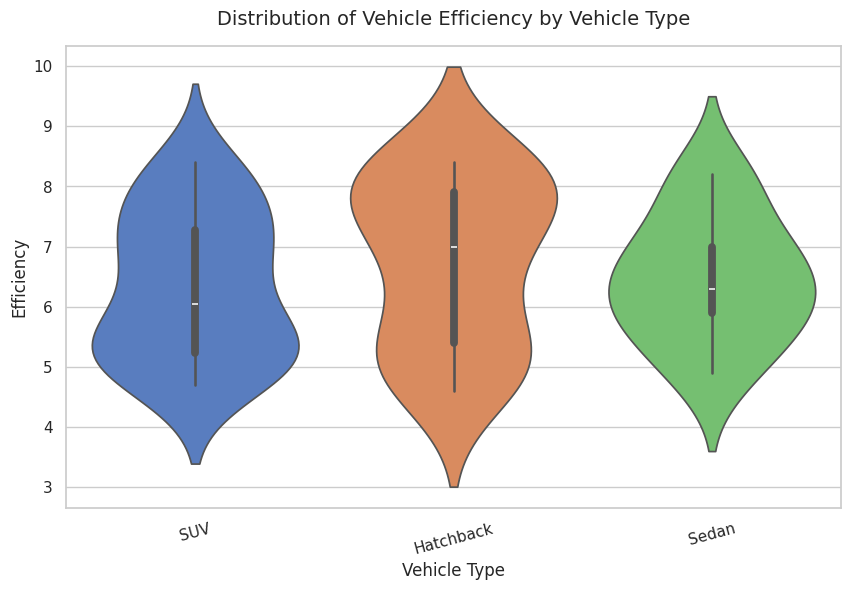

In [24]:
#3.	Create a violin plot for: Vehicle Type vs Efficiency.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="Vehicle_Type",
    y="Efficiency",
    hue="Vehicle_Type",
    palette="muted",
    legend=False,
    inner="box"
)
plt.title("Distribution of Vehicle Efficiency by Vehicle Type", fontsize=14, pad=15)
plt.xlabel("Vehicle Type", fontsize=12)
plt.ylabel("Efficiency", fontsize=12)
plt.xticks(rotation=15)
plt.show()

In [25]:
import plotly.express as px
fig = px.scatter(
    df,
    x="Battery_Capacity",  # Map X-axis
    y="Range",             # Map Y-axis
    color="Manufacturer",  # Color points uniquely by manufacturer
    size="Price",          # Map size of the bubbles to Price
    hover_name="Manufacturer",  # Bold header in the hover tooltip
    hover_data=["Top_Speed", "Efficiency"],  # Optional extra info to show on hover
    size_max=40,           # Caps maximum bubble size so they don't overlap too much
    title="EV Range vs. Battery Capacity by Manufacturer",
    labels={
        "Battery_Capacity": "Battery Capacity (kWh)",
        "Range": "Range",
        "Price": "Price",
    },
)
fig.update_layout(
    title_font_size=18,
    legend_title_text="Manufacturer",
    template="plotly_white",  # Clean, crisp white background
)
fig.show()